# XEFI
### An example of generating a basic XEFI for a mutlilayer interface, consisting of Vacuum, Polystyrene (C8H8), P3HT (C10H14S) and Silicon (Si).

In [9]:
import XEFI
import kkcalc2 as kk
import numpy as np

##### Get the refractive indexes. Can be functions of beam energy, or a list of constants for each layer, for each energy.

In [2]:
refractive_db = kk.models.asp_db_complex
refractive_air = 1.0 + 0j
refractive_P3HT = refractive_db("C10H14S", density=1.33, name="P3HT")
refractive_PS = refractive_db("C8H8", density=1.05, name="PS")
refractive_Si = refractive_db("Si", density=2.329, name="Si")

/home/matt/venvs/XEFI/lib/python3.14/site-packages/kkcalc2/models/common.py:268: UserWarning: Competing information provided for `formula mass` given a `stoichiometry`. `Stoichiometry` information precedes `formula mass`.
  warnings.warn(
/home/matt/venvs/XEFI/lib/python3.14/site-packages/kkcalc2/models/common.py:257: UserWarning: Competing information provided for `number density` and `density` given a `stoichiometry`. `Number density` information precedes `density`.
  warnings.warn(


In [3]:
# Wavelength / Beam Energy
wav = 1.54  # Å
beam_energy = XEFI.utils.wav2en(wav)  # in eV
print(f"{beam_energy:0.2f} eV")

# Angles of Incidence
angles = np.linspace(0.1, 0.4, 3000)  # in degrees

# Interfaces / Thicknesses
z = [
    0,
    -800,
    -1340,
]  # Z-coordinates for the multilayer interface

# Refractive indexes
refractive_indicies: list[kk.models.asp_complex] = [
    refractive_air,
    refractive_PS,
    refractive_P3HT,
    refractive_Si,
]


# Layer names
labels = ["Air"] + [ref.name for ref in refractive_indicies[1:]]

8050.92 eV


In [4]:
refractive_indicies2 = [
    ref.eval_refractive_index(beam_energy) if callable(ref) else ref
    for ref in refractive_indicies
]  # pyright: ignore
refractive_indicies2

[(1+0j),
 np.complex128(0.9999963734972075+4.956079743903035e-09j),
 np.complex128(0.9999953615736357+3.30990900860688e-08j),
 np.complex128(0.9999924251567754+1.7246245492878812e-07j)]

### Without Roughness

In [5]:
result = XEFI.XEF_Basic(
    energies=beam_energy,
    angles=angles,
    z=z,
    refractive_indices=refractive_indicies2,
    layer_names=labels,
    method=XEFI.XEF_method.DEV,
)

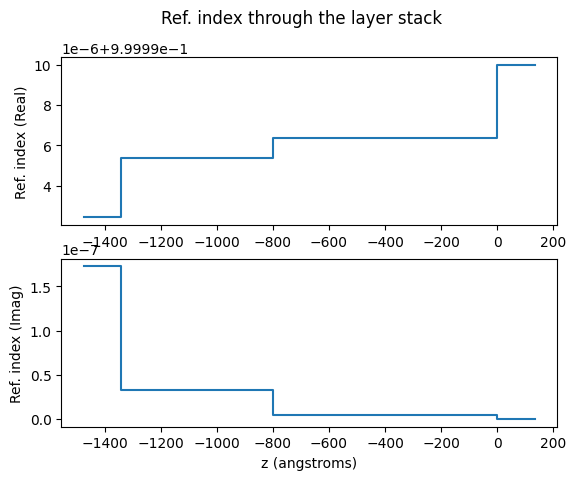

In [43]:
axes = result.graph_refractive_indexes()

Text(0.5, 1.0, 'X-ray Electric Field Intensity at $\\lambda$=1.54 Å, 8050.92 eV')

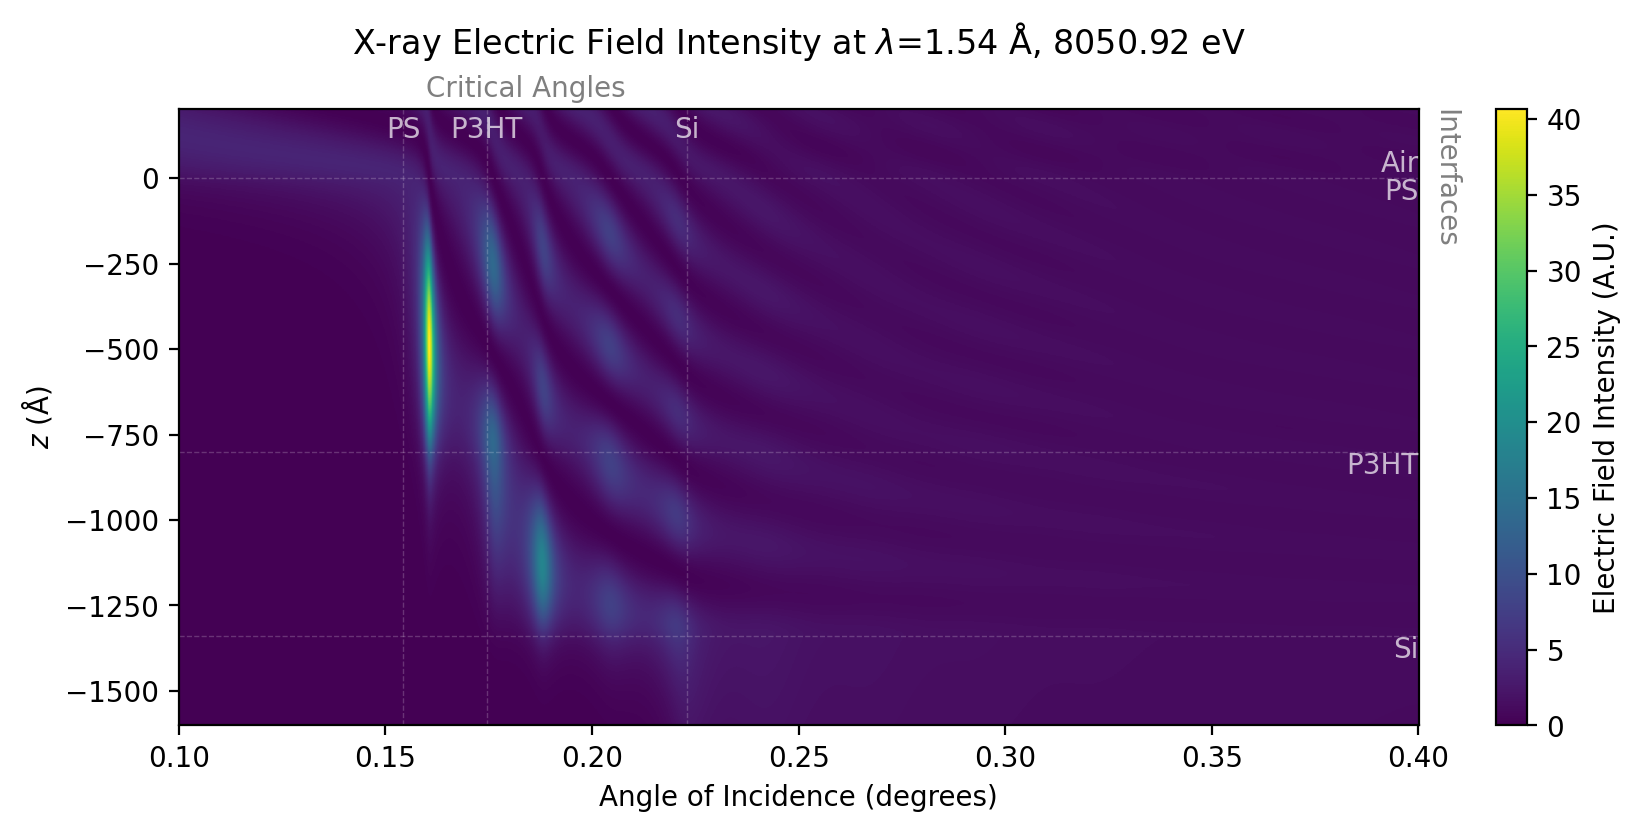

In [ ]:
z_vals = np.linspace(200, -1600, 1000)
# norm = mc.LogNorm(vmin=1e-6, vmax=10)
# norm = mc.Normalize(vmin=0, vmax=10)
# fig,ax = result.generate_pretty_figure_XEFI(z_vals, norm=norm)
fig, ax = result.generate_graphic_XEFI_map(z_vals)
ax.set_title(
    rf"X-ray Electric Field Intensity at $\lambda$={wav} Å, {beam_energy:0.2f} eV",
    pad=20,
)

In [ ]:
ax.texts[4], ax.texts[5], ax.texts[6]

(Text(1.0, 0.0, 'Air'),
 Text(0.15430558250162374, 0.99, 'PS'),
 Text(0.17451106281779089, 0.99, 'P3HT'))

### With Roughness

In [ ]:
result = XEFI.XEF_Basic(
    energies=beam_energy,
    angles=angles,
    z=z,
    refractive_indices=refractive_indicies,
    z_roughness=[40, 20, 5],
    layer_names=labels,
    method=XEFI.XEF_method.DEV,
)

Text(0.5, 1.0, 'X-ray Electric Field Intensity at $\\lambda$=1.54 Å, 8050.92 eV')

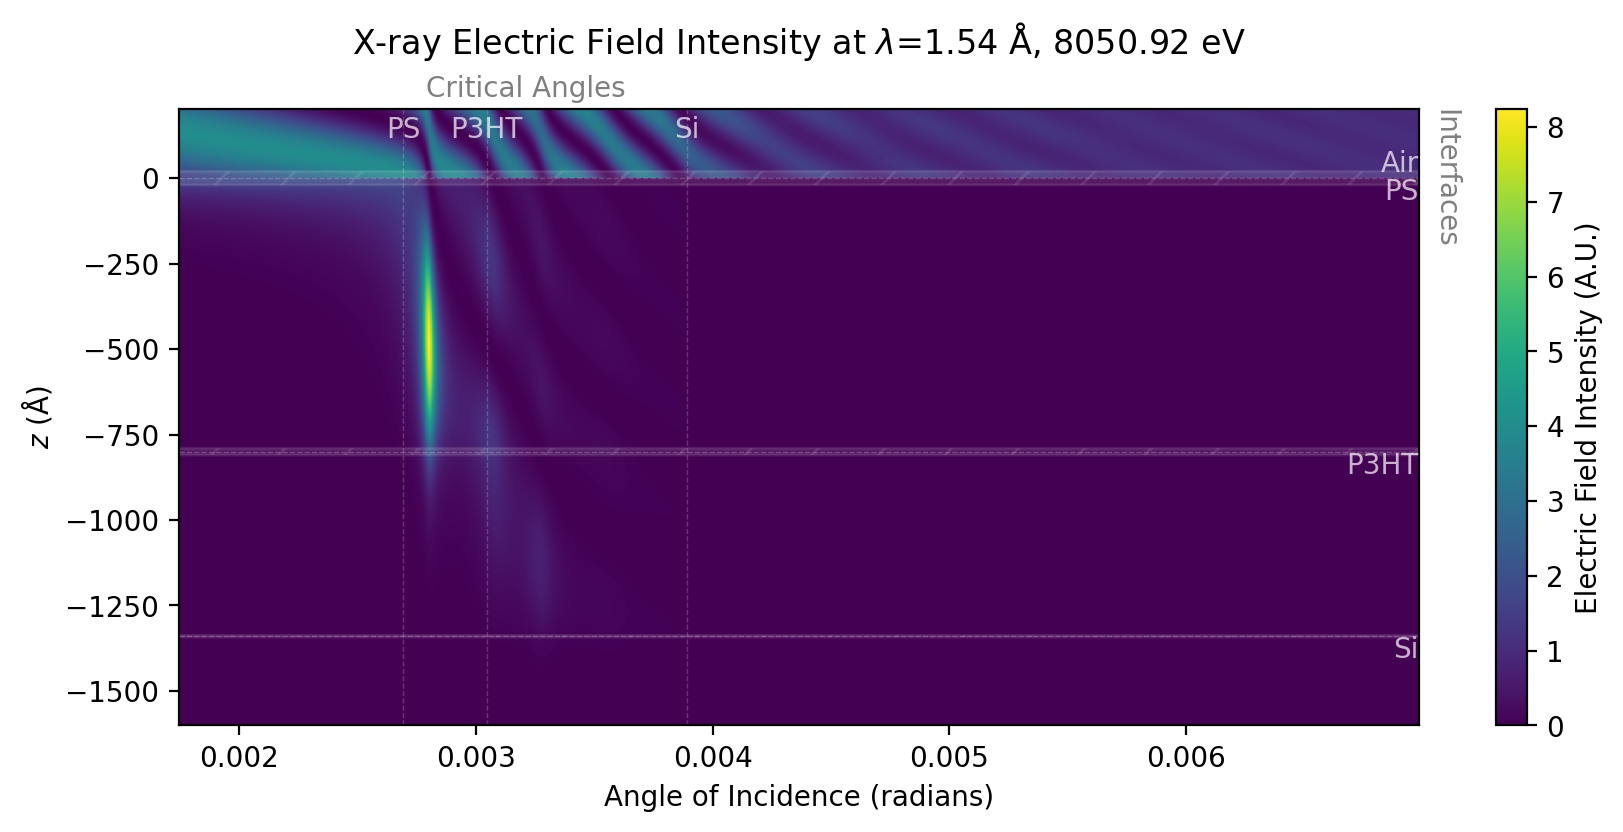

In [ ]:
z_vals = np.linspace(200, -1600, 1000)
# norm = mc.LogNorm(vmin=1e-6, vmax=10)
# norm = mc.Normalize(vmin=0, vmax=10)
# fig,ax = result.generate_pretty_figure_XEFI(z_vals, norm=norm)
fig, ax = result.generate_graphic_XEFI_map(
    z_vals, grid_roughness=True, angles_in_deg=False
)
ax.set_title(
    rf"X-ray Electric Field Intensity at $\lambda$={wav} Å, {beam_energy:0.2f} eV",
    pad=20,
)